In [1]:
import pypylon.pylon as pylon
import matplotlib.pyplot as plot
import numpy as np
import time

# Hardware triggering Basler ace acA1920-155uc

<div>
<img src="image-2.png" align="center" width="500"/>
</div>

The HW trigger unit is a simple RasperryPi generating 5Hz Signal on it's GPIO

In [2]:
# open the camera
# tlf = pylon.TlFactory.GetInstance()
camera = pylon.InstantCamera(pylon.FirstFound)
camera.Open()

# first quick check of our input signal

* most Basler cameras have chunk feature ( image meta-data transport)
* one of the chunks is 'LineStatusAll' 
* that samples all IO lines on FrameStart

In [3]:
# sample the io state with max possible framerate and chunks

In [4]:
# enable the chunk that
# samples all IO lines on every FrameStart
camera.ChunkModeActive.Value = True
camera.ChunkSelector.Value = "LineStatusAll"
camera.ChunkEnable.Value = True

In [5]:
camera.ChunkSelector.Symbolics

('Gain',
 'ExposureTime',
 'Timestamp',
 'LineStatusAll',
 'CounterValue',
 'SequencerSetActive',
 'PayloadCRC16')

In [6]:
# set max speed
camera.Height.Value = camera.Height.Min
camera.Width.Value = camera.Width.Min
camera.ExposureTime.Value = camera.ExposureTime.Min

# limit to 1khz
camera.AcquisitionFrameRateEnable.Value = True
camera.AcquisitionFrameRate.Value = 1000

print( camera.ResultingFrameRate.Value)
camera.StartGrabbingMax(1000)

io_result = []
while camera.IsGrabbing():
    with camera.RetrieveResult(1000) as result:
        time_stamp = result.TimeStamp
        io_result.append((time_stamp, result.ChunkLineStatusAll.Value))
        
camera.StopGrabbing()


366.3003663003663


In [7]:
# list of timestamp + io status
io_result[:10]

[(1993072884880, 15),
 (1993075615480, 15),
 (1993078346040, 15),
 (1993081076600, 15),
 (1993083807160, 15),
 (1993086537760, 15),
 (1993089268320, 15),
 (1993091998880, 15),
 (1993094729440, 15),
 (1993097460040, 15)]

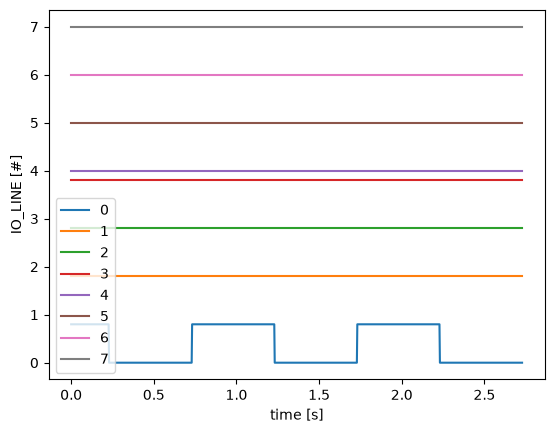

In [8]:
# simple logic analyzer :-)

# convert to numpy array
io_array = np.array(io_result)
# extract first column timestamps
x_values = io_array[:,0]
#  start with first timestamp as '0'
x_values -= x_values[0]

# extract second column io values
y_values = io_array[:,1]
# for each bit plot the graph
for bit in range(8):
    
    logic_level = ((y_values & (1<<bit)) != 0)*0.8 +bit
    # plot in seconds
    plot.plot(x_values / 1e9, logic_level, label = bit)
    
plot.xlabel("time [s]")
plot.ylabel("IO_LINE [#]")
plot.legend()
plot.show()

# Grabbing with Hardware Trigger on line4

In [9]:
# get clean powerup state
camera.UserSetSelector.Value = "Default"
camera.UserSetLoad.Execute()

setup the io section

In [10]:
camera.LineSelector.Value = "Line1"
camera.LineMode.Value = "Input"

setup the trigger / acquisition controls

In [11]:
camera.TriggerSelector.Value = "FrameStart"
camera.TriggerSource.Value = "Line1"
camera.TriggerMode.Value = "On"
camera.TriggerActivation.Value

'RisingEdge'

When trigger is already running we can just extend the grab-timeout to be larger than trigger rate

In [12]:
result = camera.GrabOne(pylon.waitForever)

When the trigger could be off when you start or much longer, that you would want to wait ....

options are:

* call `camera.RetrieveResult(pylon.waitForever)`
  but this will block until a frame is received
* poll `camera.NumReadyBuffers.Value` to check if at least one frame is available
* use the pylon background loop to capture

## triggered acquisition using the background loop

In [13]:
# definition of event handler class 
class TriggeredImage(pylon.ImageEventHandler):
    def __init__(self):
        super().__init__()
        self.grab_times = []
    def OnImageGrabbed(self, camera, grabResult):
        self.grab_times.append(grabResult.TimeStamp)

In [14]:
# create event handler instance
image_timestamps = TriggeredImage()

# register handler
# remove all other handlers
camera.RegisterImageEventHandler(image_timestamps, 
                              pylon.RegistrationMode_ReplaceAll, 
                              pylon.Cleanup_None)

# start grabbing with background loop
camera.StartGrabbingMax(100, pylon.GrabStrategy_LatestImages, pylon.GrabLoop_ProvidedByInstantCamera)
# wait ... or do something relevant
while camera.IsGrabbing():
    time.sleep(0.1)
# stop grabbing
camera.StopGrabbing()

In [ ]:
# let's check how precise the image acquisition was:
# assumption: the camera main oscillator has a much higher precision
#             than the raspberry-pi PWM output

# frame_delta = np.diff(np.array(image_timestamps.grab_times))/1e6

In [15]:
np.diff(image_timestamps.grab_times)

array([1000012640, 1000012600, 1000012680, 1000012600, 1000012600,
       1000012600, 1000012600, 1000012600, 1000013120, 1000012160,
       1000012520, 1000012800, 1000012440, 1000012600, 1000012600,
       1000012600, 1000012600, 1000012560, 1000012640, 1000012560,
       1000012600, 1000012600, 1000012560, 1000012600, 1000012560,
       1000012600, 1000012560, 1000012600, 1000013000, 1000012400,
       1000012400, 1000012600, 1000012440, 1000012560, 1000012640,
       1000012520, 1000012560, 1000012560, 1000012600, 1000012520,
       1000012600, 1000012640, 1000012440, 1000012520, 1000012640,
       1000012440, 1000012720, 1000012440, 1000012560, 1000012480,
       1000012520, 1000012600, 1000012720, 1000012360, 1000012560,
       1000012440,  999998840, 1000026280, 1000012480, 1000012560,
       1000012520, 1000012520,  999972360, 1000052680, 1000012600,
       1000012480, 1000012480, 1000012760, 1000012360, 1000012480,
       1000012520, 1000012880, 1000012160, 1000012560, 1000012

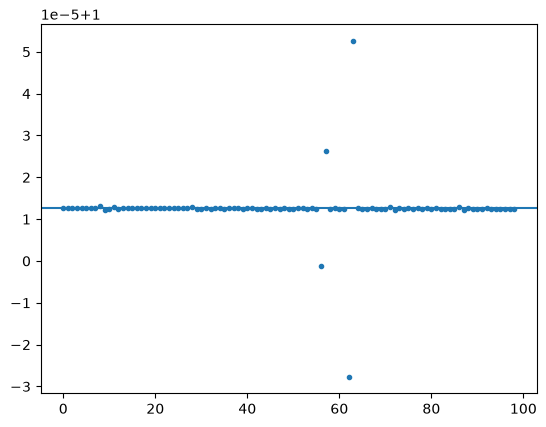

In [16]:
frame_delta_s = np.diff(np.array(image_timestamps.grab_times))/1.e9
plot.plot(frame_delta_s, ".")
plot.axhline(np.mean(frame_delta_s))

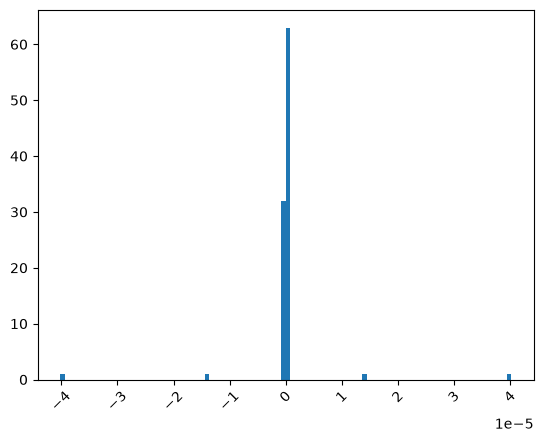

In [17]:
plot.hist(frame_delta_s  - np.mean(frame_delta_s) , bins=100)
plot.xticks(rotation=45)
plot.show()

In [4]:
camera.Close()